# Plots: Kiez Profile (Streamlit)

This notebook contains an analysis specific to the Streamlit Tool, where we want to display plots for variables in each dimension (real-estate, social, commercial), to allow a closer look at what goes on inside a Kiez, compared to the rest of the city.

## Loading of Data and Packages

In [119]:
#packages
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import re

In [120]:
#data
df = pd.read_csv("../../data/final_datasets/df_clusters_milieuschutz.csv", dtype={"plr_id": str})

In [121]:
df.sample(2)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_binary
433,10200423,Böhlener Straße,10 - Marzahn-Hellersdorf,15.83,2.163,1.149425,500.00000,-0.182322,0.792707,0.463,...,0.008976,0.005016,-0.001576,8.500000,0.000000,0.065795,1,2,0.000000,0
101,03400620,Schönholz,03 - Pankow,12.73,0.110,1.644737,723.24579,-0.074972,7.894737,0.274,...,0.003367,0.003042,0.003777,5.833333,0.270395,0.171711,0,0,0.000081,0


## Set up naming structure for plots

In [122]:
#create table with most important variables: 
id_vars = ['plr_id', 'plr_name', 'bez']

vars_keep = [
    "re_miete_niveau", #rent level, 2025
    "re_miete_trend", #rent trend, 2021-2025
    "re_altbau_share", #pre-war building share, 2022
    "re_dichte_all", #airbnb density, 2025
    "re_brw_niveau", #land value, 2022
    "soc_single_parent_household_share_2024", #single parent hh share, 2024
    "soc_transfer_benefit_share_2024", #transfer benefit share, 2024
    "soc_young_to_middle_adult_share_2025", #younger adult (18-45) share, 2025
    "soc_average_household_size_2024", #household size, 2024
    "com_exit_rate_level_2026", #business exit rate, 2026
    "com_upscale_share_level_2026", #share of upscale gastro, 2026
    "com_share_solo_level_2026", #share solo businesses, 2026
    "com_gastro_share_level_2026", #gastro establishments, 2026
    "com_n_gastro" #gastro count, 2026
]

# -----------------------------------------------------------
# Single source of truth: technical name -> display label.
# Renaming happens ONCE here -- every downstream cell reuses
# this dict instead of redefining its own labels.
# -----------------------------------------------------------
labels = {
    "re_miete_niveau": "Rent level (€/m²)",
    "re_miete_trend": "Rent trend",
    "re_altbau_share": "Share of pre-war buildings",
    "re_dichte_all": "AirBnB density (per 1000 Apts.)",
    "re_brw_niveau": "Land value (€/m²)",
    "soc_single_parent_household_share_2024": "Share of single-parent households",
    "soc_transfer_benefit_share_2024": "Share of benefit recipients",
    "soc_young_to_middle_adult_share_2025": "Share of younger adults",
    "soc_average_household_size_2024": "Average household size",
    "com_exit_rate_level_2026": "Business exit rate",
    "com_upscale_share_level_2026": "Share of upscale gastronomy",
    "com_share_solo_level_2026": "Share of solo businesses",
    "com_gastro_share_level_2026": "Share of gastronomy businesses",
    "com_n_gastro": "Number of gastro establishments"
}
# -----------------------------------------------------------
# Single source of truth: technical name -> reference year
# -----------------------------------------------------------
years_by_tech = {
    "re_miete_niveau": "2025",
    "re_miete_trend": "2021-2025",
    "re_altbau_share": "2022",
    "re_dichte_all": "2025",
    "re_brw_niveau": "2022",
    "soc_single_parent_household_share_2024": "2024",
    "soc_transfer_benefit_share_2024": "2024",
    "soc_young_to_middle_adult_share_2025": "2025",
    "soc_average_household_size_2024": "2024",
    "com_exit_rate_level_2026": "2026",
    "com_upscale_share_level_2026": "2026",
    "com_share_solo_level_2026": "2026",
    "com_gastro_share_level_2026": "2026",
    "com_n_gastro": "2026",
}

# Derived once, reused everywhere downstream -- never redefine labels/years again
years_by_label = {labels[tech]: year for tech, year in years_by_tech.items()}


## Creation: PLR-level, Bezirk-level and Berlin-level variables

In [123]:
plr_table = df[id_vars + vars_keep].rename(columns = labels)
plr_table.head(2)

,plr_id,plr_name,bez,Rent level (€/m²),Rent trend,Share of pre-war buildings,AirBnB density (per 1000 Apts.),Land value (€/m²),Share of single-parent households,Share of benefit recipients,Share of younger adults,Average household size,Business exit rate,Share of upscale gastronomy,Share of solo businesses,Share of gastronomy businesses,Number of gastro establishments
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,0.118160,10.653753,3890.584913,0.027,0.080,0.460,1.60,0.124605,0.692308,0.489786,0.017607,13.000000
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,0.228719,24.075666,3440.019389,0.025,0.027,0.479,1.77,0.078448,0.621134,0.449551,0.083164,129.333333


In [124]:
#table per bezirk
bez_table = (
    df.groupby("bez", as_index=False)[vars_keep]
      .mean().rename(columns = labels)
)

bez_table.head(10)

,bez,Rent level (€/m²),Rent trend,Share of pre-war buildings,AirBnB density (per 1000 Apts.),Land value (€/m²),Share of single-parent households,Share of benefit recipients,Share of younger adults,Average household size,Business exit rate,Share of upscale gastronomy,Share of solo businesses,Share of gastronomy businesses,Number of gastro establishments
0,01 - Mitte,17.794082,1.347286,0.357259,13.491321,2959.980489,0.037673,0.131061,0.489755,1.698776,0.141647,0.502444,0.674097,0.057012,64.040816
1,02 - Friedrichshain-Kreuzberg,17.879167,1.266000,0.468441,21.985232,3205.254636,0.041278,0.109667,0.490194,1.696667,0.134904,0.533974,0.680397,0.063827,68.421296
2,03 - Pankow,16.490714,1.275595,0.337814,9.171432,1928.902953,0.053536,0.055982,0.397196,1.793036,0.133724,0.449474,0.719685,0.033716,27.845238
3,04 - Charlottenburg-Wilmersdorf,18.259020,1.358686,0.328416,8.175632,3255.190451,0.038118,0.076627,0.372765,1.678039,0.112097,0.672306,0.606027,0.035464,40.964052
4,05 - Spandau,12.272326,0.929070,0.106747,1.242176,670.872706,0.056977,0.133140,0.351093,1.947442,0.140997,0.496798,0.755768,0.036167,14.503876
5,06 - Steglitz-Zehlendorf,14.894419,0.973651,0.166824,2.327517,1318.274188,0.041558,0.058093,0.320581,1.809070,0.137761,0.637235,0.678405,0.029812,18.980620
6,07 - Tempelhof-Schöneberg,14.410417,1.078125,0.254881,4.911122,1750.647431,0.042958,0.104979,0.374458,1.791667,0.137744,0.577060,0.697414,0.040374,31.013889
7,08 - Neukölln,13.324545,1.055062,0.291734,8.217129,1343.165340,0.044886,0.141068,0.413500,1.802273,0.154514,0.392030,0.780634,0.051283,35.742424
8,09 - Treptow-Köpenick,13.881429,0.832310,0.148194,4.145956,614.371990,0.053690,0.072500,0.381786,1.822619,0.133559,0.490571,0.722833,0.034843,17.805556
9,10 - Marzahn-Hellersdorf,11.876000,0.867186,0.015303,1.057487,502.161543,0.069125,0.112650,0.353475,1.904250,0.165384,0.462447,0.793761,0.034830,11.020833


In [125]:
#table for berlin
vars_plot = list(labels.values())  # derived from the single labels dict, not a separate list

berlin_table = pd.DataFrame({
    "Variable": vars_plot,
    "Median": df[vars_keep].median().values,
    "SD": df[vars_keep].std().values,
    "Q1": df[vars_keep].quantile(0.25).values,
    "Q3": df[vars_keep].quantile(0.75).values,
})

berlin_table = berlin_table.round(2)
berlin_table.head(15)

,Variable,Median,SD,Q1,Q3
0,Rent level (€/m²),14.85,4.41,11.60,18.00
1,Rent trend,1.00,0.76,0.57,1.52
2,Share of pre-war buildings,0.13,0.25,0.02,0.40
3,AirBnB density (per 1000 Apts.),3.27,8.85,1.13,9.27
4,Land value (€/m²),889.70,1499.61,575.70,2400.00
5,Share of single-parent households,0.04,0.02,0.04,0.06
6,Share of benefit recipients,0.08,0.06,0.05,0.14
7,Share of younger adults,0.39,0.09,0.32,0.45
8,Average household size,1.76,0.19,1.65,1.93
9,Business exit rate,0.14,0.04,0.11,0.16


## Aggregate final dataframe

In [126]:
# -----------------------------------------------------------
# Sanitize column names: spaces/slashes -> "_", collapse "__"
# -----------------------------------------------------------
plr_table.columns = (
    plr_table.columns
    .str.replace(" ", "_", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace(r"_+", "_", regex=True)
)

# -----------------------------------------------------------
# Variables to summarize (everything except id/name/bez)
# -----------------------------------------------------------
vars_plot = [c for c in plr_table.columns if c not in ["plr_id", "plr_name", "bez"]]

# -----------------------------------------------------------
# Bezirk aggregates: one row per bez, columns suffixed _bez_<stat>
# add_suffix keeps naming clean -- no MultiIndex, no lambda renaming
# -----------------------------------------------------------
bez_mean   = plr_table.groupby("bez")[vars_plot].mean().add_suffix("_bez_mean")
bez_median = plr_table.groupby("bez")[vars_plot].median().add_suffix("_bez_median")
bez_sd     = plr_table.groupby("bez")[vars_plot].std().add_suffix("_bez_sd")
bez_q1     = plr_table.groupby("bez")[vars_plot].quantile(0.25).add_suffix("_bez_q1")
bez_q3     = plr_table.groupby("bez")[vars_plot].quantile(0.75).add_suffix("_bez_q3")

bez_agg = pd.concat([bez_mean, bez_median, bez_sd, bez_q1, bez_q3], axis=1).reset_index()

plot_table = plr_table.merge(bez_agg, on="bez", how="left")

# -----------------------------------------------------------
# Berlin aggregates: a scalar per variable, broadcast to every row.
# Built as a dict and concatenated once to avoid fragmenting the
# DataFrame with repeated single-column inserts.
# -----------------------------------------------------------
berlin_cols = {}
for var in vars_plot:
    berlin_cols[f"{var}_berlin_mean"]   = plot_table[var].mean()
    berlin_cols[f"{var}_berlin_median"] = plot_table[var].median()
    berlin_cols[f"{var}_berlin_sd"]     = plot_table[var].std()
    berlin_cols[f"{var}_berlin_q1"]     = plot_table[var].quantile(0.25)
    berlin_cols[f"{var}_berlin_q3"]     = plot_table[var].quantile(0.75)

berlin_df = pd.DataFrame([berlin_cols] * len(plot_table), index=plot_table.index)
plot_table = pd.concat([plot_table, berlin_df], axis=1).copy()

In [127]:
plot_table.head(2)

,plr_id,plr_name,bez,Rent_level_(€_m²),Rent_trend,Share_of_pre-war_buildings,AirBnB_density_(per_1000_Apts.),Land_value_(€_m²),Share_of_single-parent_households,Share_of_benefit_recipients,...,Share_of_gastronomy_businesses_berlin_mean,Share_of_gastronomy_businesses_berlin_median,Share_of_gastronomy_businesses_berlin_sd,Share_of_gastronomy_businesses_berlin_q1,Share_of_gastronomy_businesses_berlin_q3,Number_of_gastro_establishments_berlin_mean,Number_of_gastro_establishments_berlin_median,Number_of_gastro_establishments_berlin_sd,Number_of_gastro_establishments_berlin_q1,Number_of_gastro_establishments_berlin_q3
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,0.118160,10.653753,3890.584913,0.027,0.080,...,0.040592,0.036271,0.023466,0.022568,0.053306,30.844086,17.833333,36.991564,8.5,39.25
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,0.228719,24.075666,3440.019389,0.025,0.027,...,0.040592,0.036271,0.023466,0.022568,0.053306,30.844086,17.833333,36.991564,8.5,39.25


## Plot: 6 Variables (2 per Dimension)

Now, let's plot the most important variables per dimension

PLR: Havelländer Ring (10200419)  |  Bezirk: 10 - Marzahn-Hellersdorf


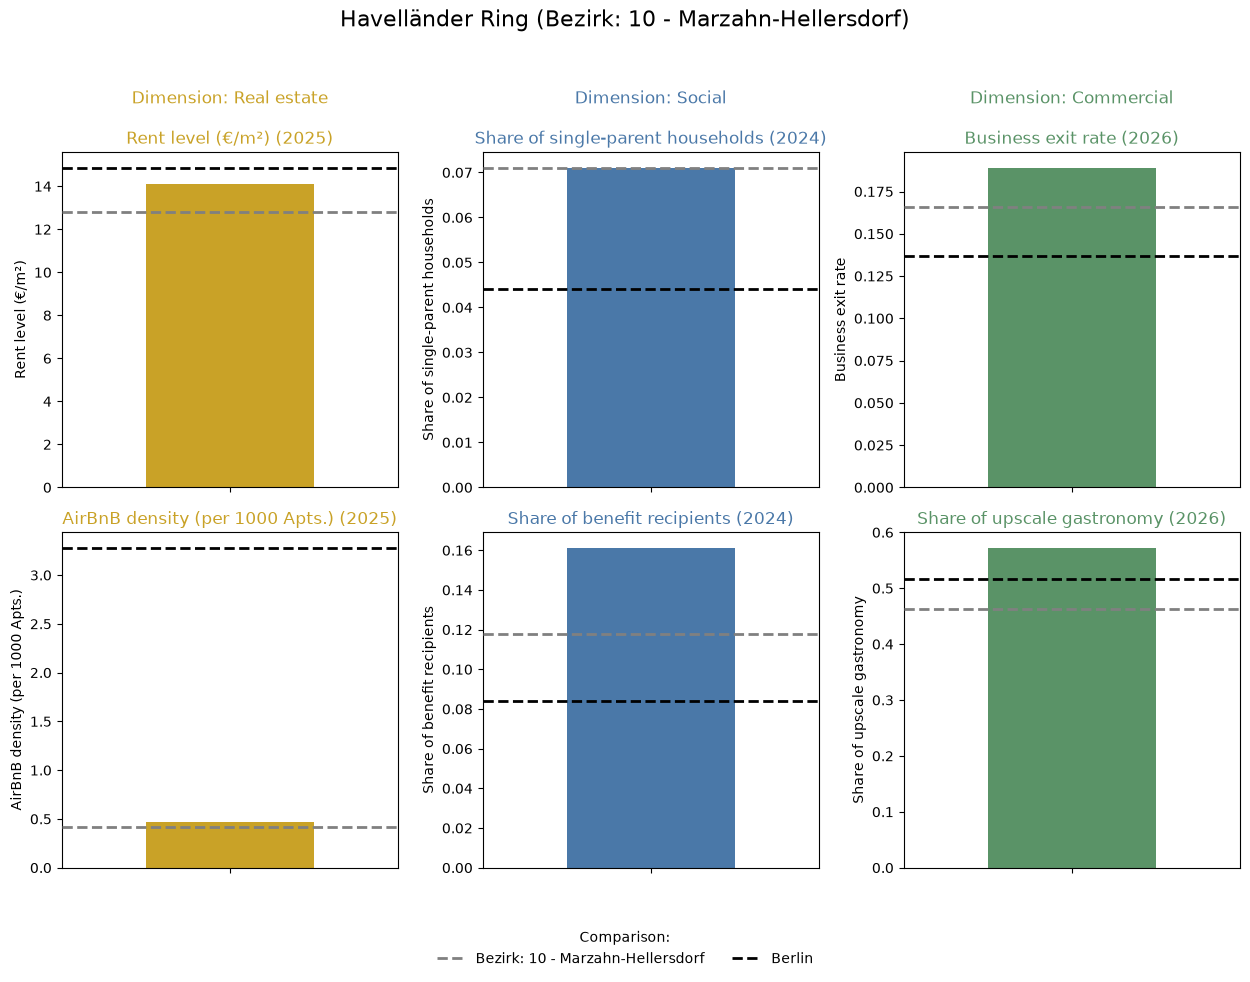

In [128]:
import re
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Settings -- change the PLR and the two variables per dimension
# -----------------------------------------------------------
plr_id = "10200419"
id_col = "plr_id"

selected_vars_raw = {
    "re":  ["Rent level (€/m²)", "AirBnB density (per 1000 Apts.)"],
    "soc": ["Share of single-parent households", "Share of benefit recipients"],
    "com": ["Business exit rate", "Share of upscale gastronomy"],
}

# NOTE: `labels` and `years_by_label` are already defined once, in the
# "Loading of Data and Packages" section above -- reused here, not redefined.

# -----------------------------------------------------------
# All variables use the median as the reference
# -----------------------------------------------------------

# -----------------------------------------------------------
# Dimension colors
# -----------------------------------------------------------
dimension_colors = {
    "re": "#C9A227",   # Real estate -- yellow
    "soc": "#4A78A8",  # Social -- blue
    "com": "#5A9367",  # Commercial -- green
}

dimension_labels = {
    "re": "Real estate",
    "soc": "Social",
    "com": "Commercial",
}

# -----------------------------------------------------------
# Get the row for this PLR
# -----------------------------------------------------------
row = plot_table.loc[plot_table[id_col] == plr_id].iloc[0]
plr_name = row.get("plr_name", plr_id)
bez_name = row["bez"]

# -----------------------------------------------------------
# Six-way plot: 2 rows x 3 columns, one column per dimension
# -----------------------------------------------------------
dims = ["re", "soc", "com"]
fig, axes = plt.subplots(2, 3, figsize=(4.2 * 3, 4.5 * 2))

for col, dim in enumerate(dims):
    for row_idx in range(2):
        ax = axes[row_idx][col]
        var_raw = selected_vars_raw[dim][row_idx]
        var = re.sub(r"_+", "_", var_raw.replace(" ", "_").replace("/", "_"))

        plr_val = row[var]

        bez_center = row[f"{var}_bez_median"]
        berlin_center = row[f"{var}_berlin_median"]

        ax.bar([0], [plr_val], width=0.5, color=dimension_colors[dim],zorder=2)

        bez_line, = ax.plot([-0.5, 0.5], [bez_center, bez_center], color="gray",
                             linestyle="--", linewidth=2, zorder=3)
        berlin_line, = ax.plot([-0.5, 0.5], [berlin_center, berlin_center], color="black",
                                linestyle="--", linewidth=2, zorder=3)

        ax.set_xticks([0])
        ax.set_xticklabels([""])
        ax.set_xlim(-0.5, 0.5)
        ax.set_ylabel(var_raw)

        if row_idx == 0:
            ax.set_title(f"Dimension: {dimension_labels[dim]}\n\n{var_raw} ({years_by_label[var_raw]})",
                         color=dimension_colors[dim])
        else:
            ax.set_title(f"{var_raw} ({years_by_label[var_raw]})", color=dimension_colors[dim])

fig.legend(
    handles=[bez_line, berlin_line],
    labels=[f"Bezirk: {bez_name}", "Berlin"],
    title="Comparison:",
    loc="upper center", bbox_to_anchor=(0.5, 0.02),
    ncol=2, frameon=False,
)

fig.suptitle(f"{plr_name} (Bezirk: {bez_name})", fontsize=16, y=1.03)

print(f"PLR: {plr_name} ({plr_id})  |  Bezirk: {bez_name}")

fig.tight_layout(rect=[0, 0.05, 1, 1])
#fig.savefig(f"six_way_{plr_id}.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot: 3 x 2 Variables (2 per Dimension)

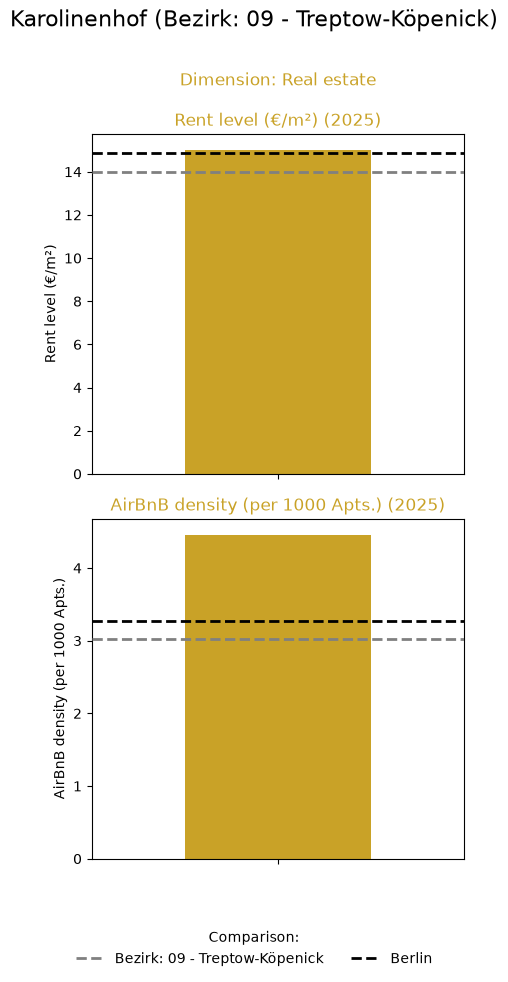

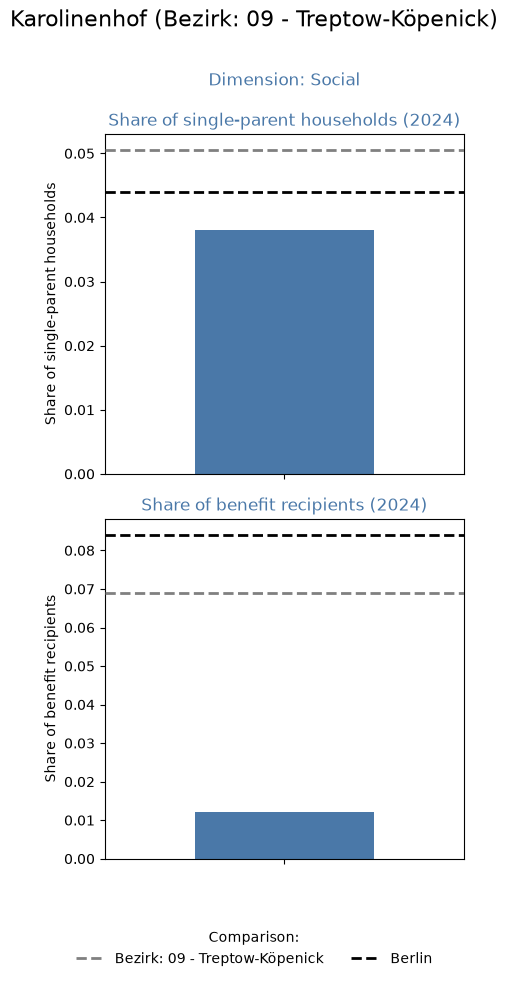

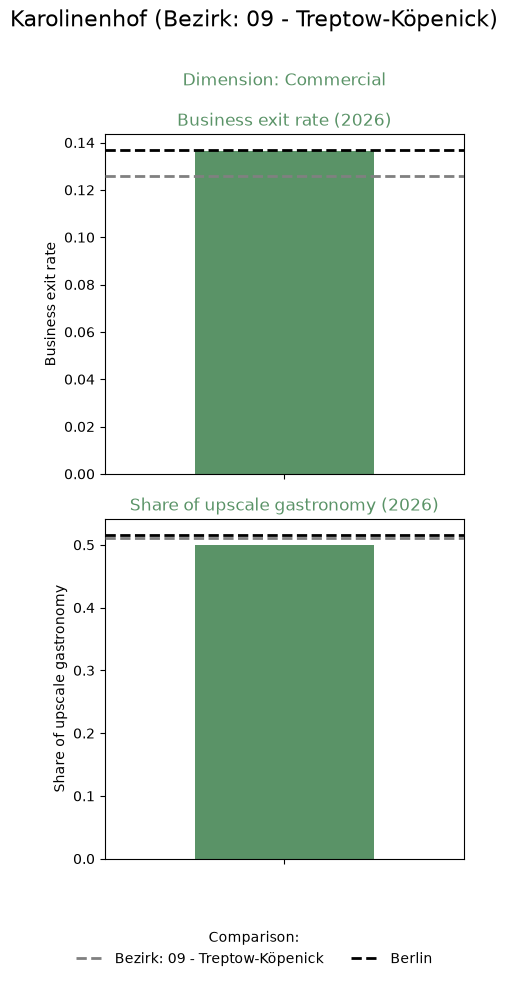

PLR: Karolinenhof (09301227)  |  Bezirk: 09 - Treptow-Köpenick


In [129]:
# -----------------------------------------------------------
# Settings -- change the PLR and the two variables per dimension
# -----------------------------------------------------------
plr_id = "09301227"
id_col = "plr_id"

selected_vars_raw = {
    "re":  ["Rent level (€/m²)", "AirBnB density (per 1000 Apts.)"],
    "soc": ["Share of single-parent households", "Share of benefit recipients"],
    "com": ["Business exit rate", "Share of upscale gastronomy"],
}

#`labels` and `years_by_label` are already defined once, in the
# "Loading of Data and Packages" section above -- reused here, not redefined.

# -----------------------------------------------------------
# All variables use the median as the reference
# -----------------------------------------------------------

# -----------------------------------------------------------
# Dimension colors
# -----------------------------------------------------------
dimension_colors = {
    "re": "#C9A227",   # Real estate -- yellow
    "soc": "#4A78A8",  # Social -- blue
    "com": "#5A9367",  # Commercial -- green
}

dimension_labels = {
    "re": "Real estate",
    "soc": "Social",
    "com": "Commercial",
}

# -----------------------------------------------------------
# Get the row for this PLR
# -----------------------------------------------------------
row = plot_table.loc[plot_table[id_col] == plr_id].iloc[0]
plr_name = row.get("plr_name", plr_id)
bez_name = row["bez"]

# -----------------------------------------------------------
# One separate figure per dimension, variables stacked vertically
# -----------------------------------------------------------
for dim in ["re", "soc", "com"]:
    vars_in_dim = selected_vars_raw[dim]

    fig, axes = plt.subplots(len(vars_in_dim), 1, figsize=(4.5, 4.5 * len(vars_in_dim)))

    for i, var_raw in enumerate(vars_in_dim):
        ax = axes[i]
        var = re.sub(r"_+", "_", var_raw.replace(" ", "_").replace("/", "_"))

        plr_val = row[var]

        bez_center = row[f"{var}_bez_median"]
        berlin_center = row[f"{var}_berlin_median"]

        ax.bar([0], [plr_val], width=0.5, color=dimension_colors[dim], zorder=2)

        bez_line, = ax.plot([-0.5, 0.5], [bez_center, bez_center], color="gray",
                             linestyle="--", linewidth=2, zorder=3)
        berlin_line, = ax.plot([-0.5, 0.5], [berlin_center, berlin_center], color="black",
                                linestyle="--", linewidth=2, zorder=3)

        ax.set_xticks([0])
        ax.set_xticklabels([""])
        ax.set_xlim(-0.5, 0.5)
        ax.set_ylabel(var_raw)

        if i == 0:
            ax.set_title(f"Dimension: {dimension_labels[dim]}\n\n{var_raw} ({years_by_label[var_raw]})",
                         color=dimension_colors[dim])
        else:
            ax.set_title(f"{var_raw} ({years_by_label[var_raw]})", color=dimension_colors[dim])

    fig.legend(
        handles=[bez_line, berlin_line],
        labels=[f"Bezirk: {bez_name}", "Berlin"],
        title="Comparison:",
        loc="upper center", bbox_to_anchor=(0.5, 0.0),
        ncol=2, frameon=False,
    )

    fig.suptitle(f"{plr_name} (Bezirk: {bez_name})", fontsize=16, y=1.01)

    fig.tight_layout(rect=[0, 0.04, 1, 1])
    #fig.savefig(f"{dim}_{plr_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

print(f"PLR: {plr_name} ({plr_id})  |  Bezirk: {bez_name}")